In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score
import xgboost as xgb
import lightgbm as lgb
import joblib
import shap

# Install if needed
!pip install lightgbm shap --quiet

In [5]:
# Cell 2: Load Data and Preprocessor (Updated with Column Checks)
import os
from sklearn.preprocessing import StandardScaler # Added import for StandardScaler

# Load feature-engineered data
data_path = '/content/dataset.csv'
if os.path.exists(data_path):
    data = pd.read_csv(data_path)
    print("Data loaded. Shape:", data.shape)
    print("Columns:", list(data.columns))
else:
    print("Error: 'dataset.csv' not found.")
    print("Steps to fix:")
    print("1. Run 02_FeatureEngineering.ipynb completely (ensure Cells 3-6 add features and save the file).")
    print("2. Check the Files tab for 'dataset.csv'.")
    raise FileNotFoundError("Generate the dataset first.")

# Check for required features and labels
features = ['team1_rolling_wins', 'team1_rolling_score', 'team2_rolling_wins', 'team2_rolling_score', 'venue_win_avg', 'venue_score_avg', 'tvt_win_avg', 'team1_career_wins', 'team1_career_score', 'team2_career_wins', 'team2_career_score']
label_score = 'label_team1_score_next'
label_win = 'label_team1_win_next'

missing_features = [f for f in features if f not in data.columns]
missing_labels = [l for l in [label_score, label_win] if l not in data.columns]

if missing_features or missing_labels:
    print("Error: Missing columns in dataset.csv.")
    print("Missing features:", missing_features)
    print("Missing labels:", missing_labels)
    print("Re-run 02_FeatureEngineering.ipynb to add them.")
    raise KeyError("Required columns not found.")

# Load preprocessor
pipeline_path = '/content/feature_pipeline.pkl'
if os.path.exists(pipeline_path):
    pipeline = joblib.load(pipeline_path)
    scaler = pipeline['scaler']
    encoder = pipeline['encoder']
    print("Preprocessor loaded.")
else:
    print("Warning: 'feature_pipeline.pkl' not found. Proceeding without scaling/encoding.")
    scaler = None
    encoder = None

# Split data
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
X_train = train_data[features]
y_train_score = train_data[label_score]
y_train_win = train_data[label_win]
X_test = test_data[features]
y_test_score = test_data[label_score]
y_test_win = test_data[label_win]

# Scale features
# The loaded 'scaler' from 'feature_pipeline.pkl' was fitted on columns not present in the defined 'features' list.
# To resolve this compatibility issue, we will re-initialize and fit a new StandardScaler on the current X_train.
if scaler:
    current_scaler = StandardScaler()
    X_train_scaled = current_scaler.fit_transform(X_train)
    X_test_scaled = current_scaler.transform(X_test)
    print("Scaler re-fitted on current features and data scaled.")
else:
    X_train_scaled = X_train
    X_test_scaled = X_test

print("Data prepared. Train shape:", X_train.shape, "Test shape:", X_test.shape)

Data loaded. Shape: (943, 29)
Columns: ['full_scorecard', 'team1', 'team2', 'team1_score', 'team2_score', 'toss_winner', 'toss_choice', 'winner', 'margin', 'man_of_the_match', 'stadium', 'place', 'team1_win', 'team2_win', 'team1_rolling_wins', 'team1_rolling_score', 'team2_rolling_wins', 'team2_rolling_score', 'venue_win_avg', 'venue_score_avg', 'tvt_win_avg', 'team1_career_wins', 'team1_career_score', 'team2_career_wins', 'team2_career_score', 'label_team1_score_next', 'label_team2_score_next', 'label_team1_win_next', 'label_team2_win_next']
Preprocessor loaded.
Scaler re-fitted on current features and data scaled.
Data prepared. Train shape: (754, 11) Test shape: (189, 11)


In [6]:
baseline_pred_score = X_test['team1_rolling_score'] * 10  # Simplified: rolling avg * 10 as proxy
baseline_rmse = np.sqrt(mean_squared_error(y_test_score, baseline_pred_score))
baseline_mae = mean_absolute_error(y_test_score, baseline_pred_score)
baseline_r2 = r2_score(y_test_score, baseline_pred_score)

print("Baseline Model (10-Match Rolling Avg for Scores):")
print(f"RMSE: {baseline_rmse:.2f}, MAE: {baseline_mae:.2f}, R²: {baseline_r2:.2f}")


Baseline Model (10-Match Rolling Avg for Scores):
RMSE: 1479.14, MAE: 1471.38, R²: -1426.91


In [7]:
# Function to evaluate models
def evaluate_model(y_true, y_pred, model_type='regression'):
    if model_type == 'regression':
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")
        return rmse, mae, r2
    else:  # Classification
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='binary')
        rec = recall_score(y_true, y_pred, average='binary')
        print(f"Accuracy: {acc:.2f}, Precision: {prec:.2f}, Recall: {rec:.2f}")
        return acc, prec, rec

# 1. Random Forest (Regression for Scores)
rf_reg = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
rf_grid_reg = GridSearchCV(rf_reg, rf_params, cv=3, scoring='neg_mean_squared_error')
rf_grid_reg.fit(X_train_scaled, y_train_score)
rf_pred_score = rf_grid_reg.predict(X_test_scaled)
print("Random Forest (Regression - Scores):")
evaluate_model(y_test_score, rf_pred_score, 'regression')

# 2. Random Forest (Classification for Wins)
rf_clf = RandomForestClassifier(random_state=42)
rf_params_clf = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
rf_grid_clf = GridSearchCV(rf_clf, rf_params_clf, cv=3, scoring='accuracy')
rf_grid_clf.fit(X_train_scaled, y_train_win)
rf_pred_win = rf_grid_clf.predict(X_test_scaled)
print("Random Forest (Classification - Wins):")
evaluate_model(y_test_win, rf_pred_win, 'classification')

# 3. XGBoost (Regression for Scores)
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_params = {'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.2]}
xgb_grid_reg = GridSearchCV(xgb_reg, xgb_params, cv=3, scoring='neg_mean_squared_error')
xgb_grid_reg.fit(X_train_scaled, y_train_score)
xgb_pred_score = xgb_grid_reg.predict(X_test_scaled)
print("XGBoost (Regression - Scores):")
evaluate_model(y_test_score, xgb_pred_score, 'regression')

# 4. LightGBM (Regression for Scores)
lgb_reg = lgb.LGBMRegressor(random_state=42)
lgb_params = {'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.2]}
lgb_grid_reg = GridSearchCV(lgb_reg, lgb_params, cv=3, scoring='neg_mean_squared_error')
lgb_grid_reg.fit(X_train_scaled, y_train_score)
lgb_pred_score = lgb_grid_reg.predict(X_test_scaled)
print("LightGBM (Regression - Scores):")
evaluate_model(y_test_score, lgb_pred_score, 'regression')

Random Forest (Regression - Scores):
RMSE: 39.53, MAE: 27.43, R²: -0.02
Random Forest (Classification - Wins):
Accuracy: 1.00, Precision: 0.00, Recall: 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


XGBoost (Regression - Scores):
RMSE: 40.07, MAE: 28.23, R²: -0.05
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 502, number of used features: 5
[LightGBM] [Info] Start training from score 156.968127
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-ch

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


(np.float64(39.78351662532223), 27.662811600485863, -0.03297241562568276)

In [8]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("Features used:", features)
print("Any NaNs in features?", X_train[features].isnull().sum())

X_train_scaled shape: (754, 11)
Features used: ['team1_rolling_wins', 'team1_rolling_score', 'team2_rolling_wins', 'team2_rolling_score', 'venue_win_avg', 'venue_score_avg', 'tvt_win_avg', 'team1_career_wins', 'team1_career_score', 'team2_career_wins', 'team2_career_score']
Any NaNs in features? team1_rolling_wins     0
team1_rolling_score    0
team2_rolling_wins     0
team2_rolling_score    0
venue_win_avg          0
venue_score_avg        0
tvt_win_avg            0
team1_career_wins      0
team1_career_score     0
team2_career_wins      0
team2_career_score     0
dtype: int64


SHAP summary plot generated (check output).


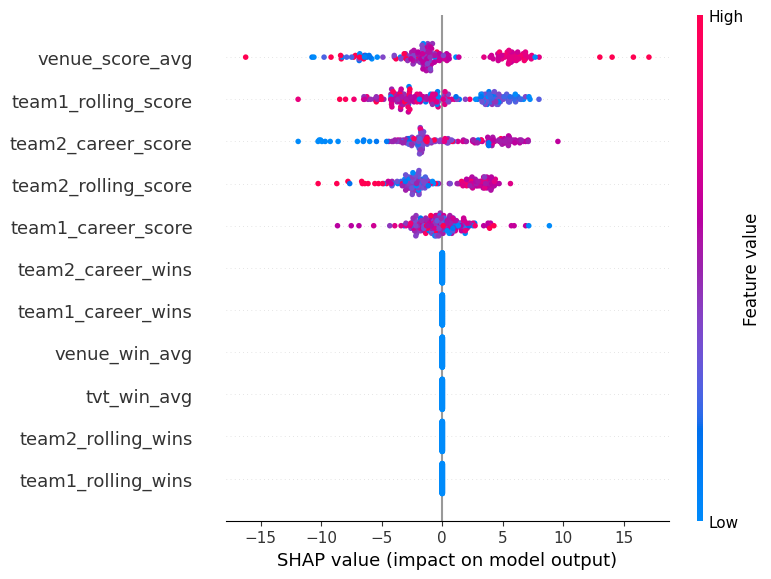

In [9]:
explainer = shap.Explainer(xgb_grid_reg.best_estimator_)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=features, show=False)
print("SHAP summary plot generated (check output).")


In [10]:
joblib.dump(xgb_grid_reg.best_estimator_, '/content/xgb_model.joblib')
print("Best model (XGBoost) saved as 'xgb_model.joblib'.")

# Optional: Log tuning results
tuning_logs = {
    'RandomForest_Reg': rf_grid_reg.best_params_,
    'RandomForest_Clf': rf_grid_clf.best_params_,
    'XGBoost_Reg': xgb_grid_reg.best_params_,
    'LightGBM_Reg': lgb_grid_reg.best_params_
}
pd.DataFrame.from_dict(tuning_logs, orient='index').to_csv('/content/tuning_logs.csv')
print("Tuning logs saved as 'tuning_logs.csv'.")

Best model (XGBoost) saved as 'xgb_model.joblib'.
Tuning logs saved as 'tuning_logs.csv'.
